In [ ]:
# Import all required libraries for the TED Talk recommendation system
# Purpose: Load necessary modules for data processing, NLP, and machine learning

# Data manipulation and analysis libraries
import numpy as np  # Numerical operations and array handling
import pandas as pd  # Data manipulation and analysis
import matplotlib.pyplot as plt  # Data visualization and plotting

# Natural Language Processing libraries
import nltk  # Natural Language Toolkit for text processing
import string  # String operations and punctuation handling
import warnings  # Warning management
from scipy.stats import pearsonr  # Statistical correlation calculation
from nltk.corpus import stopwords  # Common words to filter out
from wordcloud import WordCloud  # Generate word cloud visualizations

# Machine Learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer  # Convert text to numerical features
from sklearn.metrics.pairwise import cosine_similarity  # Calculate similarity between texts


Matplotlib is building the font cache; this may take a moment.
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


In [ ]:
# Download NLTK stopwords and configure warnings
# Purpose: Prepare NLTK resources and suppress unnecessary warnings

nltk.download('stopwords')  # Download English stopwords list for text preprocessing
warnings.filterwarnings('ignore')  # Suppress warning messages for cleaner output

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anbuc\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [ ]:
# Load the TED Talk dataset from CSV file
# Purpose: Import the dataset and display first few rows to understand the data structure

df = pd.read_csv('Data/tedx_datase.csv')  # Load TED Talk data from CSV file
print(df.head())  # Display first 5 rows to inspect data structure and content

                                idx       main_speaker  \
0  8d2005ec35280deb6a438dc87b225f89     Alexandra Auer   
1  b3072cd11f40eb57fd259555264476c6  Elizabeth Gilbert   
2  4adc9fee977fa04c357ed4c9b52aa3cc       Butterscotch   
3  59c641a72b495d522a7932145d6c02b3         Ethan Lisi   
4  d227f2faf6ec185e54436d86463f499b      Daniel Finkel   

                                               title  \
0                    The intangible effects of walls   
1  It's OK to feel overwhelmed. Here's what to do...   
2                                  "Accept Who I Am"   
3               What it's really like to have autism   
4              Can you solve the sea monster riddle?   

                                             details           posted  \
0  More barriers exist now than at the end of Wor...  Posted Apr 2020   
1  If you're feeling anxious or fearful during th...  Posted Apr 2020   
2  Firing off her formidable beatboxing skills, m...  Posted Apr 2020   
3  "Autism is not a di

In [ ]:
# Check dataset dimensions
# Purpose: Understand the size of the dataset (number of rows and columns)

df.shape  # Returns tuple (rows, columns) showing total number of TED talks and features

(4467, 7)

In [ ]:
# Check for missing values in the dataset
# Purpose: Identify which columns have null/missing values and how many

df.isnull().sum()  # Count missing values in each column to assess data quality

idx                0
main_speaker       1
title              0
details            0
posted             0
url                0
num_views       4258
dtype: int64

In [ ]:
# Extract year and month from the 'posted' column
# Purpose: Parse date information from text format to separate year and month columns

splitted = df['posted'].str.split(' ', expand=True)  # Split "Posted Apr 2020" into separate parts

# Creating columns for month and year of the talk
df['year'] = splitted[2].astype('int')  # Extract year (3rd element) and convert to integer
df['month'] = splitted[1]  # Extract month (2nd element) as string

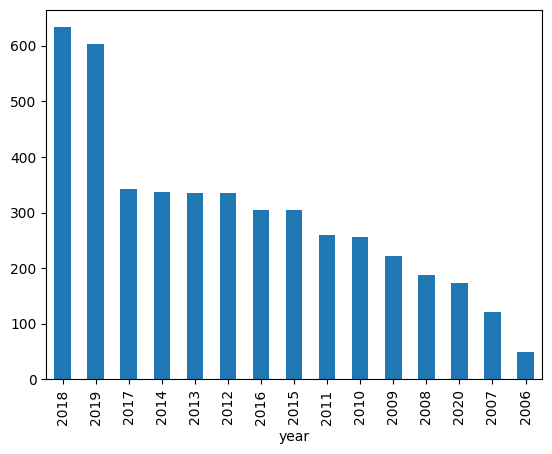

In [ ]:
# Visualize distribution of TED talks by year
# Purpose: Create a bar chart showing how many talks were posted each year

df['year'].value_counts().plot.bar()  # Count talks per year and create bar chart
plt.show()  # Display the visualization

In [ ]:
# Prepare text data for recommendation system
# Purpose: Combine title and details into single text field and clean the dataset

# Let's combine the title and the details of the talk.
df['details'] = df['title'] + ' ' + df['details']  # Merge title and details for richer text content

# Removing the unnecessary information
df = df[['main_speaker', 'details']]  # Keep only speaker name and combined text content
df.dropna(inplace = True)  # Remove rows with missing values
df.head()  # Display first few rows of cleaned dataset

,main_speaker,details
0,Alexandra Auer,The intangible effects of walls More barriers ...
1,Elizabeth Gilbert,It's OK to feel overwhelmed. Here's what to do...
2,Butterscotch,"""Accept Who I Am"" Firing off her formidable be..."
3,Ethan Lisi,"What it's really like to have autism ""Autism i..."
4,Daniel Finkel,Can you solve the sea monster riddle? Accordin...


In [ ]:
# Create backup copy of processed data
# Purpose: Preserve original processed data before applying text preprocessing

# We would like to have a copy of our data for future use.
data = df.copy()  # Create independent copy to avoid modifying original during preprocessing

In [ ]:
# Define function to remove common English stopwords
# Purpose: Filter out common words (the, and, is, etc.) to focus on meaningful content

def remove_stopwords(text):
  stop_words = stopwords.words('english')  # Get list of common English stopwords

  imp_words = []  # List to store important (non-stopword) words

  # Storing the important words
  for word in str(text).split():  # Split text into individual words
    word = word.lower()  # Convert to lowercase for consistent comparison
    
    if word not in stop_words:  # Keep word if it's not a stopword
      imp_words.append(word)

  output = " ".join(imp_words)  # Join important words back into text

  return output

In [ ]:
# Apply stopword removal to all talk descriptions
# Purpose: Clean text data by removing common words to improve recommendation accuracy

df['details'] = df['details'].apply(lambda text: remove_stopwords(text))  # Apply stopword removal to each talk
df.head()  # Display first few rows to see cleaned text

,main_speaker,details
0,Alexandra Auer,intangible effects walls barriers exist end wo...
1,Elizabeth Gilbert,ok feel overwhelmed. here's next feeling anxio...
2,Butterscotch,"""accept am"" firing formidable beatboxing skill..."
3,Ethan Lisi,"really like autism ""autism disease; another wa..."
4,Daniel Finkel,"solve sea monster riddle? according legend, ev..."


In [ ]:
# Remove punctuation marks from text data
# Purpose: Further clean text by removing punctuation to focus on word content

punctuations_list = string.punctuation  # Get all punctuation characters (!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~)

def cleaning_punctuations(text):
    signal = str.maketrans('', '', punctuations_list)  # Create translation table to remove punctuation
    return text.translate(signal)  # Apply translation to remove punctuation

# Apply punctuation removal to all talk descriptions
df['details'] = df['details'].apply(lambda x: cleaning_punctuations(x))  # Remove punctuation from each talk
df.head()  # Display first few rows to see final cleaned text

,main_speaker,details
0,Alexandra Auer,intangible effects walls barriers exist end wo...
1,Elizabeth Gilbert,ok feel overwhelmed heres next feeling anxious...
2,Butterscotch,accept am firing formidable beatboxing skills ...
3,Ethan Lisi,really like autism autism disease another way ...
4,Daniel Finkel,solve sea monster riddle according legend ever...


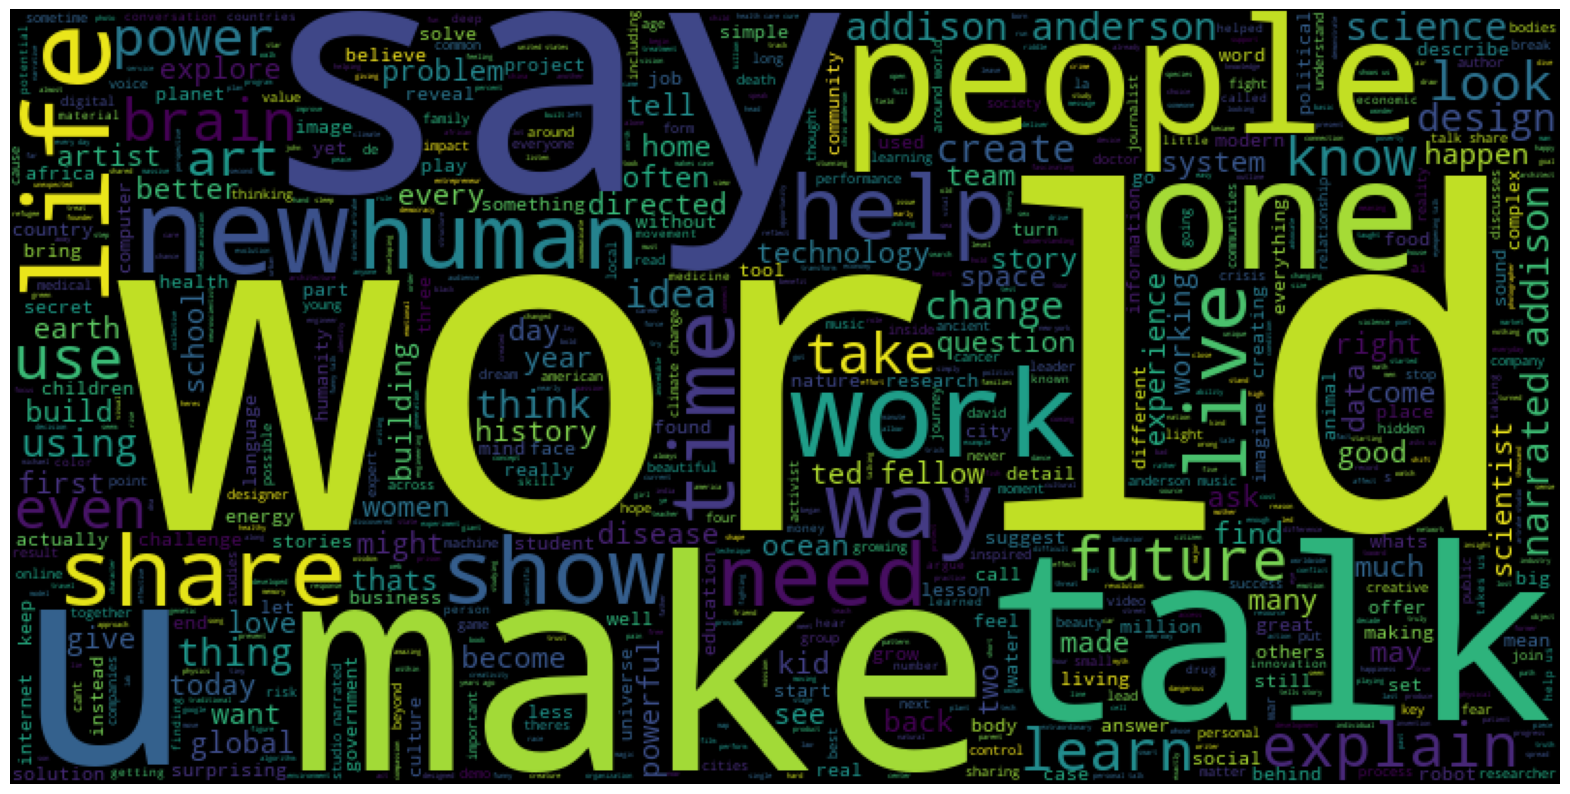

In [ ]:
# Generate word cloud visualization of all talk content
# Purpose: Create visual representation of most frequent words across all TED talks

details_corpus = " ".join(df['details'])  # Combine all talk descriptions into single text corpus

plt.figure(figsize=(20, 20))  # Set large figure size for better visibility
wc = WordCloud(max_words=1000,  # Limit to 1000 most frequent words
               width=800,        # Set word cloud width
               height=400).generate(details_corpus)  # Generate word cloud from corpus
plt.axis('off')  # Remove axes for cleaner visualization
plt.imshow(wc)  # Display the word cloud
plt.show()  # Show the plot

In [ ]:
# Initialize and train TF-IDF vectorizer for text-to-number conversion
# Purpose: Convert text content into numerical vectors for similarity calculations

vectorizer = TfidfVectorizer(analyzer = 'word')  # Create TF-IDF vectorizer using word-level analysis
vectorizer.fit(df['details'])  # Train vectorizer on all talk descriptions to build vocabulary

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [ ]:
# Calculate similarity scores between input text and all talks in dataset
# Purpose: Compute both cosine similarity and Pearson correlation for comprehensive matching

def get_similarities(talk_content, data=df):

    # Getting vector for the input talk_content.
    talk_array1 = vectorizer.transform(talk_content).toarray()  # Convert input text to TF-IDF vector

    # We will store similarity for each row of the dataset.
    sim = []  # List to store cosine similarity scores
    pea = []  # List to store Pearson correlation scores
    
    for idx, row in data.iterrows():  # Iterate through each talk in dataset
        details = row['details']

        # Getting vector for current talk.
        talk_array2 = vectorizer.transform(
            data[data['details'] == details]['details']).toarray()  # Convert current talk to TF-IDF vector

        # Calculating cosine similarities
        cos_sim = cosine_similarity(talk_array1, talk_array2)[0][0]  # Calculate cosine similarity (0-1 scale)

        # Calculating pearson correlation
        pea_sim = pearsonr(talk_array1.squeeze(), talk_array2.squeeze())[0]  # Calculate Pearson correlation (-1 to 1 scale)

        sim.append(cos_sim)  # Store cosine similarity
        pea.append(pea_sim)  # Store Pearson correlation

    return sim, pea  # Return both similarity measures

In [ ]:
# Main recommendation function that finds and displays similar talks
# Purpose: Generate ranked list of most similar TED talks based on input content

def recommend_talks(talk_content, data=data):

    data['cos_sim'], data['pea_sim'] = get_similarities(talk_content)  # Calculate similarity scores for all talks

    data.sort_values(by=['cos_sim', 'pea_sim'], ascending=[
                     False, False], inplace=True)  # Sort by similarity scores (highest first)

    display(data[['main_speaker', 'details']].head())  # Display top 5 most similar talks

In [ ]:
# Test the recommendation system with time management topic
# Purpose: Demonstrate the system by finding talks similar to time management content

talk_content = ['Time Management and working\
hard to become successful in life']  # Input text about time management
recommend_talks(talk_content)  # Get recommendations for similar talks

,main_speaker,details
1758,Laura Vanderkam,How to gain control of your free time There ar...
2173,Philip Krinks,Finding your personal mission in life Philip K...
66,Fang Ruan,Management lessons from Chinese business and p...
1658,Chimamanda Ngozi Adichie,We should all be feminists We teach girls that...
3190,Nirmalya Kumar,India's invisible innovation Can India become ...


In [ ]:
# Test the recommendation system with climate change topic
# Purpose: Demonstrate the system by finding talks similar to environmental/climate content

talk_content = ['Climate change and impact on the health\
. How can we change this world by reducing carbon footprints?']  # Input text about climate change
recommend_talks(talk_content)  # Get recommendations for similar talks

,main_speaker,details
2867,Didier Sornette,How we can predict the next financial crisis T...
575,Tomás Chor,Turbulence: one of the great unsolved mysterie...
1900,Mia Nacamulli,What is obesity? Obesity is an escalating glob...
4081,José Antonio Abreu,The El Sistema music revolution José Antonio A...
345,Philip Freeman,A day in the life of an ancient Celtic Druid A...
